# CUPED

We call 'Controlled-experiment Using Pre-Experiment Data' (CUPED) a scenario where a treatment is randomly assigned to participants, and we have pre-experiment data of participants like pre-treatment outcome.

Treatment - new product category for users.

We will test hypothesis:

$H_o$ - There is no difference in LTV between treatment and control groups.

$H_a$ - There is a difference in LTV between treatment and control groups.

# Causal Assumptions

**Unconfoundedness**: random assignment of treatment. Will be tested with SRM and Balance Check

**Overlap**: each unit has a non-zero probability of assignment to every arm. By design

**SUTVA**: no interference and consistent treatment definitions. By design

**Pre-treatment covariate**: exists and predicts outcome

## Data

For the analysis you need data in pandas dataframe:
- treatment column in binary format (1/0)
- outcome column numeric format, measured after treatment time
- user_id column (Optional, but useful)
- confounders columns (Optional, measured before treatment time, numeric format, used for causal assumption check, includes covariates for CUPED)

We will take data from Causalis DGP. Read more at https://causalis.causalcraft.com/articles/make_cuped_tweedie_26

In [1]:
from causalis.scenarios.cuped.dgp import generate_cuped_tweedie_26
from causalis.data_contracts import CausalData

data = generate_cuped_tweedie_26(return_causal_data=False, include_oracle=True)
data.head()


,y,d,tenure_months,avg_sessions_week,spend_last_month,discount_rate,platform_ios,platform_web,m,m_obs,tau_link,g0,g1,cate,y_pre,_latent_A,y_pre_2
0,3.734763,0.0,14.187461,2.0,57.355300,0.158164,1.0,0.0,0.5,0.5,0.103825,8.487966,9.416605,0.928639,17.972138,0.304717,10.783283
1,0.746406,1.0,6.352893,3.0,46.700946,0.085722,0.0,0.0,0.5,0.5,0.030781,8.487966,8.753301,0.265335,0.000000,-1.039984,0.000000
2,13.040584,1.0,18.910153,9.0,80.136187,0.175115,1.0,0.0,0.5,0.5,0.357355,8.487966,12.133915,3.645949,34.771837,0.750451,24.866330
3,34.582113,1.0,7.927627,4.0,33.718224,0.152718,1.0,0.0,0.5,0.5,0.065554,8.487966,9.063025,0.575059,349.163943,0.940565,209.498366
4,0.000000,1.0,11.106925,2.0,92.064518,0.077390,0.0,0.0,0.5,0.5,0.056036,8.487966,8.977172,0.489206,0.000000,-1.951035,0.243980


In [2]:
causaldata = CausalData(df = data,
                        treatment='d',
                        outcome='y',
                        confounders=['avg_sessions_week',
                                     'spend_last_month',
                                     'discount_rate',
                                     'platform_ios',
                                     'platform_web',
                                     'y_pre',
                                     'y_pre_2'])
causaldata

CausalData(df=(20000, 9), treatment='d', outcome='y', confounders=['avg_sessions_week', 'spend_last_month', 'discount_rate', 'platform_ios', 'platform_web', 'y_pre', 'y_pre_2'])

# EDA

In [3]:
from causalis.shared import outcome_stats
outcome_stats(causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,0,10049,8.867136,21.097599,0.0,0.0,0.0,0.276901,9.266134,24.454852,347.095992
1,1,9951,9.870188,25.879015,0.0,0.0,0.0,0.000000,10.409916,27.439125,956.413897


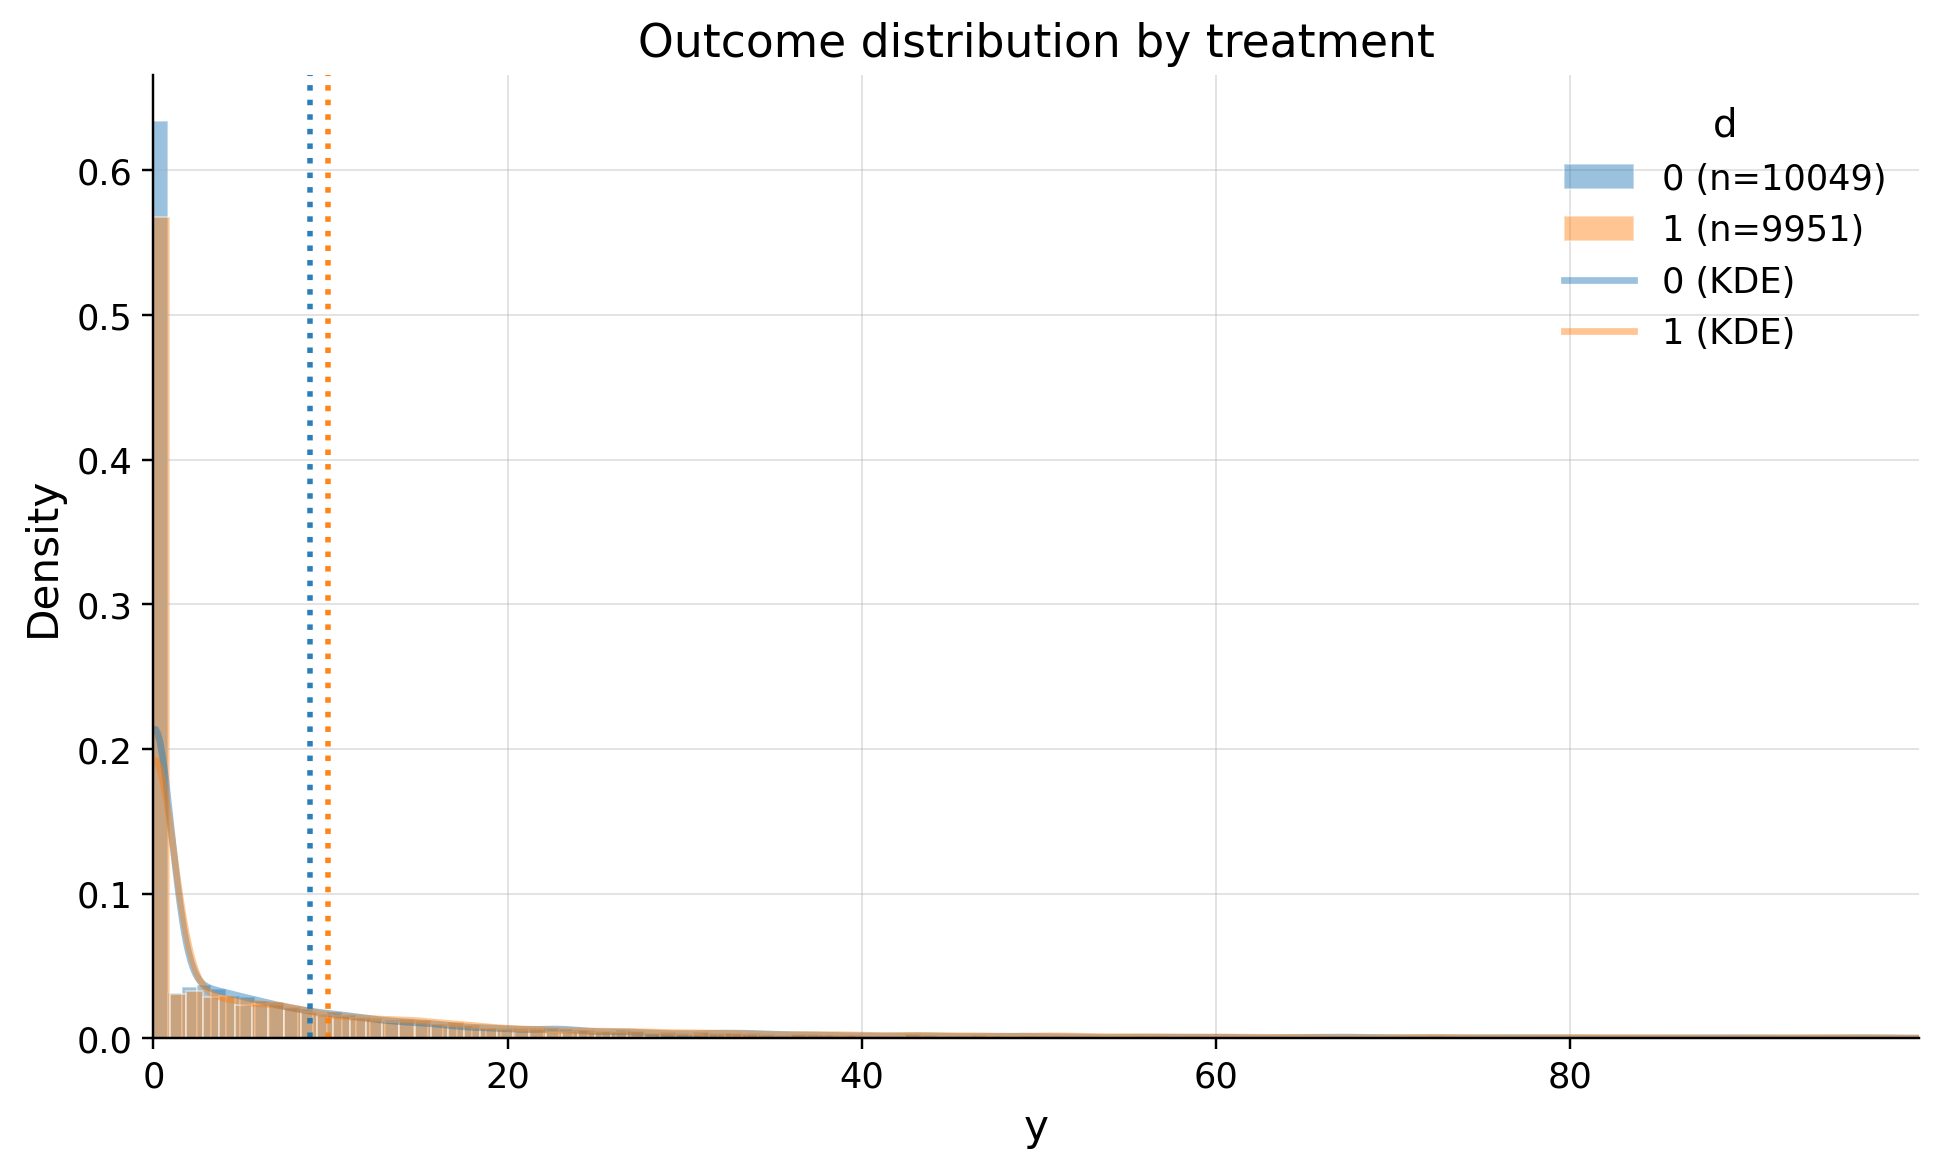

In [4]:
from causalis.shared import outcome_plot_dist, outcome_plot_boxplot
outcome_plot_dist(causaldata)

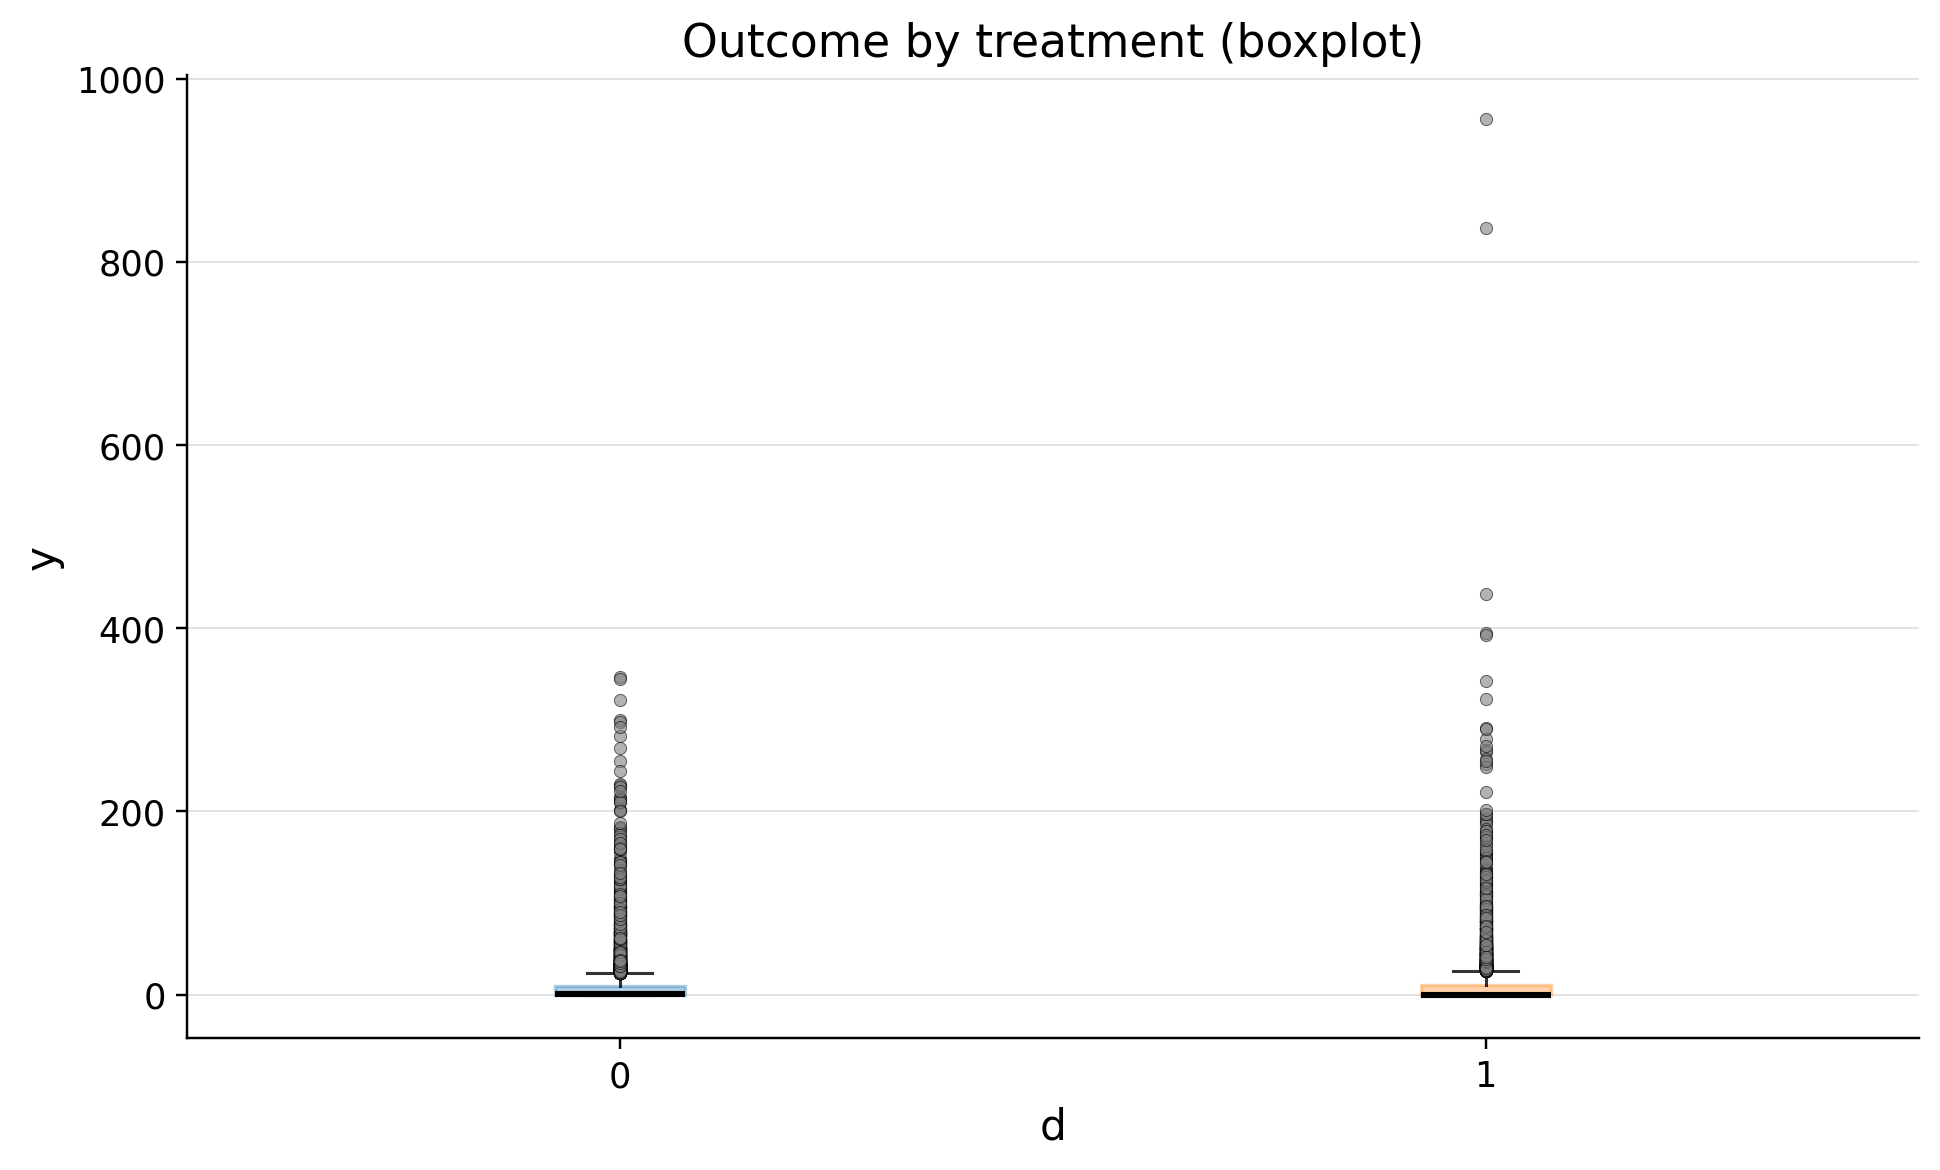

In [5]:
from causalis.shared import outcome_plot_boxplot
outcome_plot_boxplot(causaldata)

In [6]:
from causalis.shared import outcome_outliers
outcome_outliers(causaldata)

,treatment,n,outlier_count,outlier_rate,lower_bound,upper_bound,has_outliers,method,tail
0,0,10049,1080,0.107473,-13.899201,23.165335,True,iqr,both
1,1,9951,1063,0.106823,-15.614875,26.024791,True,iqr,both


We see heavy tale distribution

# SRM

Some system is randomly splitting users. Half must have new onboarding, other half has not. We should monitor the split with SRM test. Read more at https://causalis.causalcraft.com/articles/srm

In [7]:
from causalis.shared import check_srm

check_srm(assignments=causaldata, target_allocation={0: 0.5, 1: 0.5}, alpha=0.001)

SRMResult(status=no SRM, p_value=0.48833, chi2=0.4802)

# Confounders balance

In [8]:
from causalis.shared import confounders_balance

confounders_balance(causaldata)

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,spend_last_month,73.787667,75.159017,1.371350,0.019726,0.20812
1,platform_ios,0.304309,0.297357,0.006952,-0.015158,0.96771
2,y_pre,7928.516448,20967.672427,13039.155979,0.014621,0.36084
3,y_pre_2,4760.192129,12583.709202,7823.517073,0.014621,0.38473
4,avg_sessions_week,4.963379,5.015677,0.052297,0.012405,0.49401
5,discount_rate,0.100420,0.099996,0.000424,-0.006421,0.36146
6,platform_web,0.050950,0.050749,0.000202,-0.000918,1.00000


- SRM is good
- SMD < 0.1 and ks_pvalue > 0.05

Split is random. Uncofoundedness is true

# Inference with CUPED

Read more about model specification at https://causalis.causalcraft.com/articles/cuped-model

In [9]:
from causalis.scenarios.cuped.model import CUPEDModel

model = CUPEDModel().fit(causaldata, covariates=['y_pre', 'y_pre_2'])

In [10]:
result = model.estimate()
result.summary()

,value
field,
estimand,ATE
model,CUPEDModel
value,"0.8155 (ci_abs: 0.2724, 1.3587)"
value_relative,"9.0633 (ci_rel: 2.7548, 15.3718)"
alpha,0.0500
p_value,0.0033
is_significant,True
n_treated,9951
n_control,10049


# Refutation

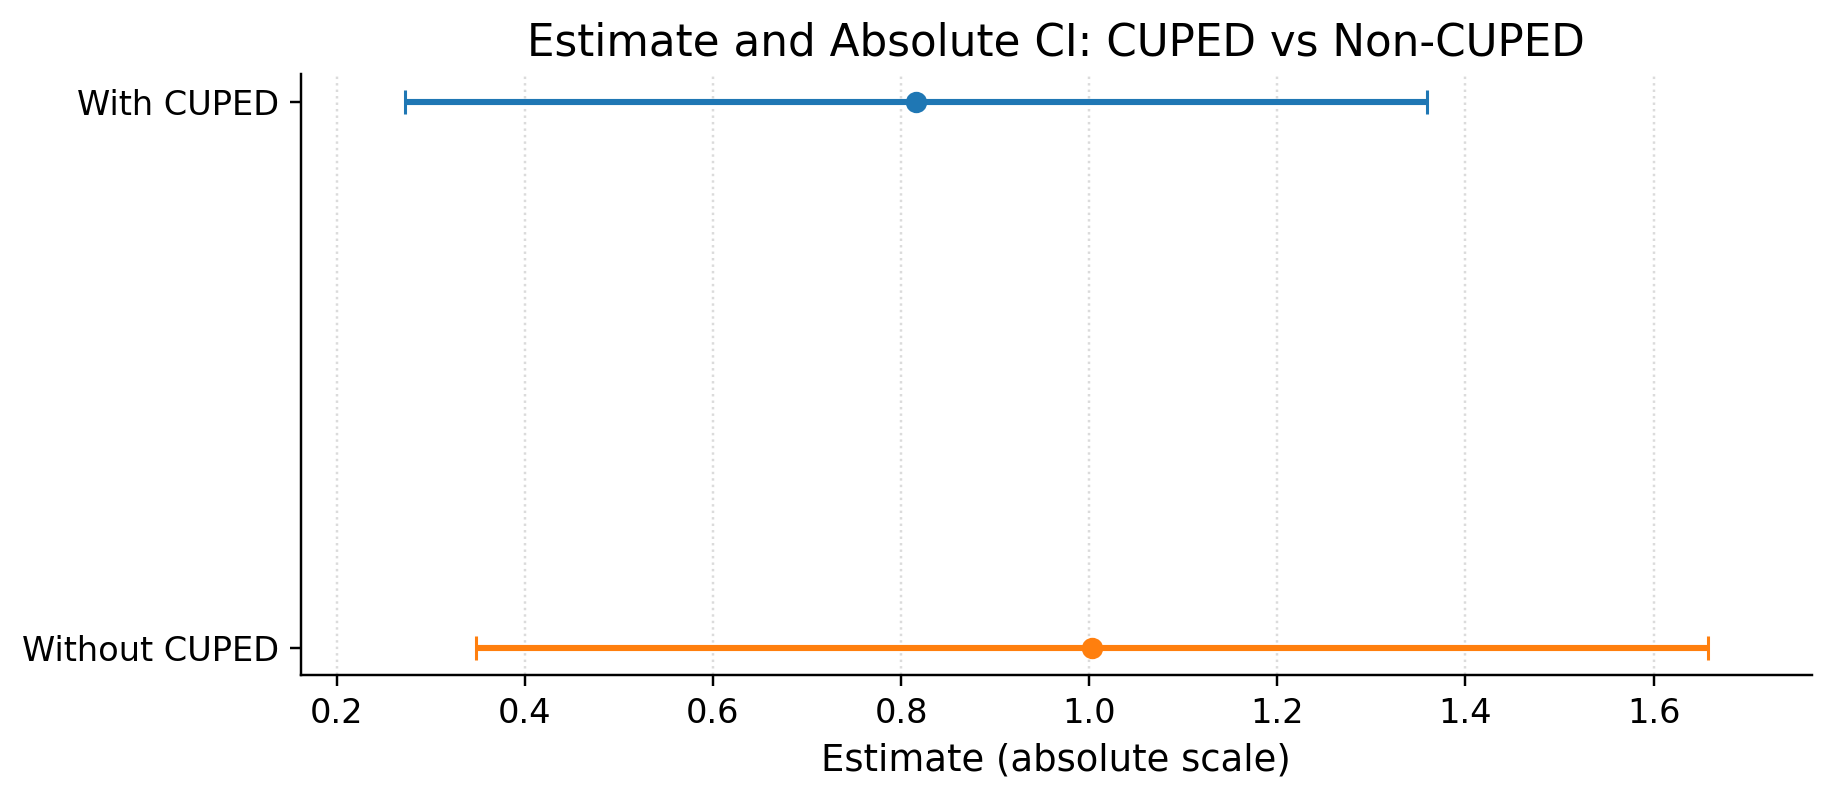

In [11]:
from causalis.scenarios.cuped import cuped_forest_plot
cuped_forest_plot(result)

In [15]:
print("var reduction with CUPED %:", result.diagnostic_data.variance_reduction_pct_same_cov)

var reduction with CUPED %: 31.179489563275986


In [13]:
from causalis.scenarios.cuped.refutation import (
    regression_assumptions_table_from_estimate,
    style_regression_assumptions_table,
)

assumptions_table = regression_assumptions_table_from_estimate(
    result,
    style_regression_assumptions_table=style_regression_assumptions_table,
)
assumptions_table

,test_id,test,flag,value,threshold,message
0,design_rank,Design rank,GREEN,"rank=6, k=6",rank == k,Design matrix is full rank.
1,condition_number,Condition number,GREEN,3335417.561613,<= 1.000e+08,Condition number is within expected range.
2,near_duplicates,Near-duplicate covariates,YELLOW,1,red if >= 3,Near-duplicate covariate pairs detected.
3,vif,Variance inflation factor,RED,6485299680.233781,"yellow: > 20, red: > 40",Very large VIF indicates severe multicollinearity.
4,ate_gap,Adjusted vs naive ATE,GREEN,0.561334,"yellow: > 2.00, red: > 2.50",Adjusted and naive ATE are reasonably aligned.
5,residual_tails,Residual extremes,RED,max|std resid|=27.8,"yellow > 7, red > 10",Extremely large standardized residuals; outliers likely dominate.
6,leverage,Leverage,RED,"max_h=0.91, n_high=653","yellow if max_h > 5*0.0006, red if max_h > max(0.5, 10*0.0006)",Extreme leverage points detected.
7,cooks,Cook's distance,RED,"max=1301, n_high=778","yellow if max Cook's > 0.1, red if > 1",Strongly influential observations detected.
8,hc23_stability,HC2/HC3 stability,GREEN,"min(1-h)=9.004e-02, n_tiny=0",min(1-h) >= 1.0e-06,HC2/HC3 stability check passed.
9,winsor_sensitivity,Winsor sensitivity,GREEN,0.304010,"yellow: > 1.00 SE, red: > 2.00 SE",Winsorized refit is close to baseline ATE.


let's compare it to oracle effect

In [16]:
print(f"Ground truth ATE is {data['cate'].mean()}")

Ground truth ATE is 1.2383515933360814
